In [1]:
import torch
import umap.umap_ as umap
import numpy as np
import pandas as pd
import sklearn
import umap.umap_ as umap
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

/root/miniconda3/envs/myconda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import random
def setup_seed(seed: int = 42, deterministic: bool = False):

    random.seed(seed)
    
    np.random.seed(seed)
    
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  
    
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.enabled = False  
        
seed = 42
setup_seed(seed=seed)

In [3]:
expr=pd.read_csv('expr.csv').iloc[:,1:]
meta=pd.read_csv("stateFate_inVitro_metadata.csv")
scaler = StandardScaler()
scaler.fit(expr)
xs = pd.DataFrame(scaler.transform(expr), index = expr.index, columns = expr.columns)
pca = sklearn.decomposition.PCA(n_components = 50)
xp = pd.DataFrame(pca.fit_transform(xs))
um = umap.UMAP(n_components = 2, metric = 'euclidean',n_neighbors = 10, random_state=3407)
data_day2=torch.from_numpy(xp[meta['Time point']==2].values)
data_day4=torch.from_numpy(xp[meta['Time point']==4].values)
data_day6=torch.from_numpy(xp[meta['Time point']==6].values)
x_seq=torch.cat([data_day2,data_day4,data_day6])
xu = um.fit_transform(x_seq)
data={'expr':expr,
      'meta':meta,
      'scaler':scaler,
      'xs':xs,
      'pca':pca,
      'xp':xp,
      'um':um,
      'xu':xu}
# torch.save(data,'weinreb.pt')

/root/miniconda3/envs/myconda/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [4]:
from scope import computations as cmp
from scope import clustering as cl
from scope import pre_match as pm
from scope import visualizations as vi

data_lst = [data_day2,data_day4,data_day6]
time_steps = [2,4,6]

cluster_centers, labels_list, best_k = cl.kmeans_auto([d.cuda() for d in data_lst],tol=1e-4,method='calinski_harabasz',max_k=8)
print(best_k)

max_variance_differences = cmp.max_adjacent_covariance_diagonal_differences(data_lst)
print(max_variance_differences)

# scal = cmp.eps_scalar()
eps_func = cmp.piecewise_eps_function(time_steps, max_variance_differences,snr=0.95,min_eps=0.1) 


[2, 2, 5]
[32.03110940378177, 31.23644371246502]


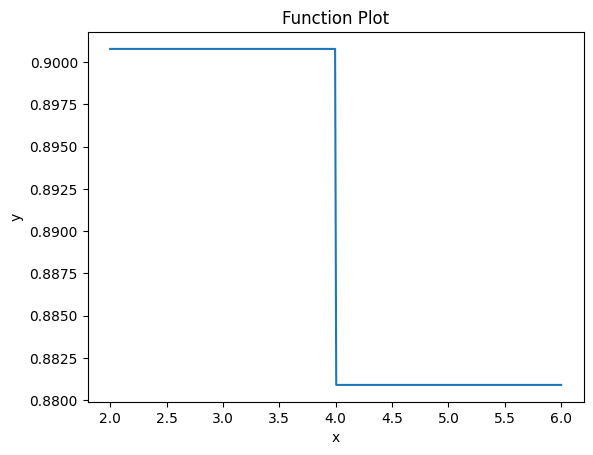

In [5]:
x = np.linspace(time_steps[0], time_steps[-1], 400)

y = [eps_func(x_i) for x_i in x]

plt.plot(x, y)

plt.title('Function Plot')
plt.xlabel('x')
plt.ylabel('y')

plt.show()

In [6]:
all_points_map, msf_edges = pm.calculate_evolutionary_graph([c.cpu().numpy() for c in cluster_centers],metric='euclidean')

INFO: Preparing data for visualization...
INFO: UMAP model provided. Transforming high-dimensional data to 2D...


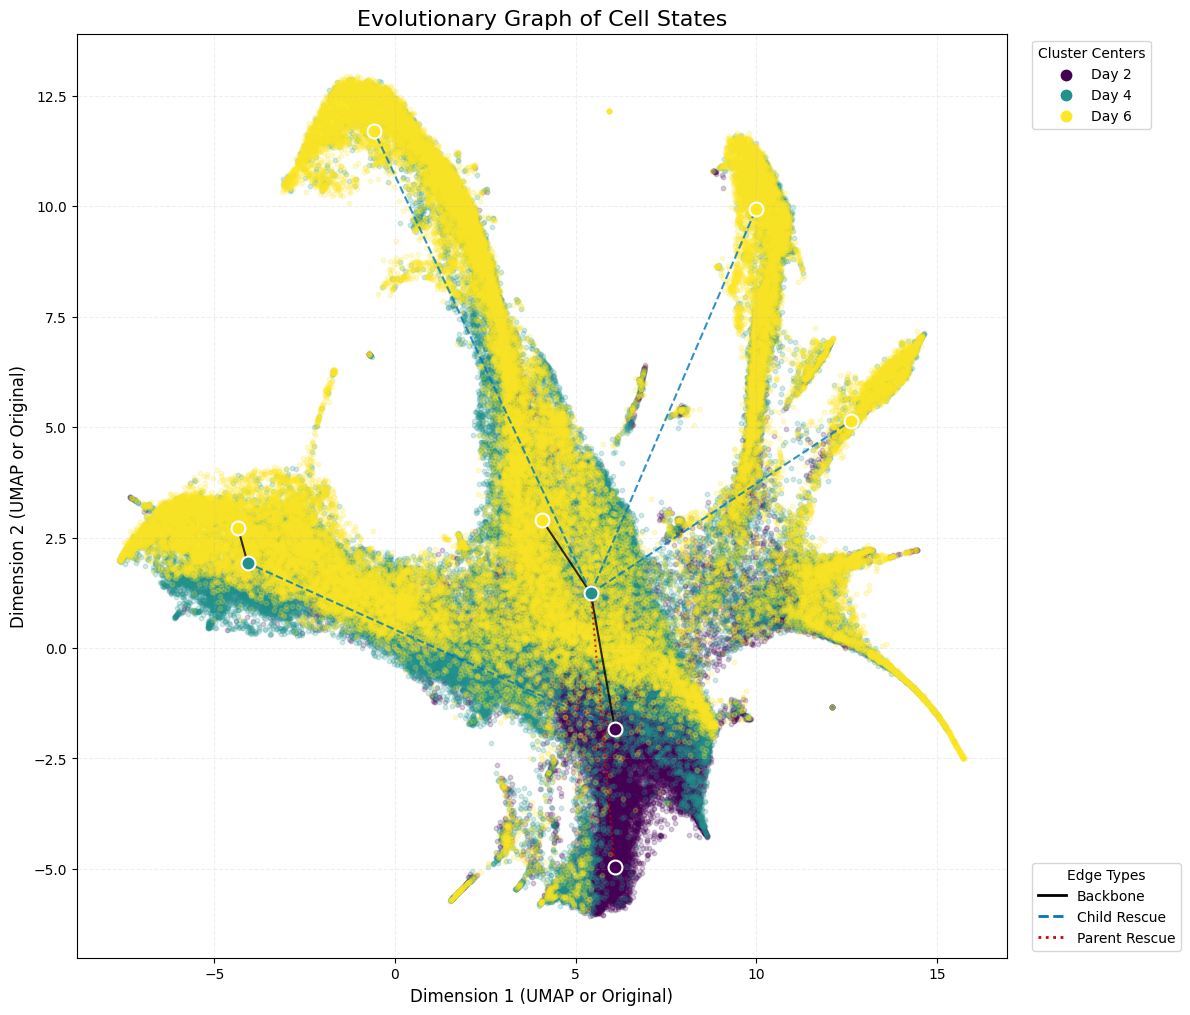

In [7]:
#all_points_map, msf_edges = pm.calculate_evolutionary_graph([c.cpu().numpy() for c in cluster_centers],metric='euclidean')
vi.visualize_full_evolution(
    raw_data=[d.cpu().numpy() for d in data_lst],
    centers=[c.cpu().numpy() for c in cluster_centers],
    all_points_map=all_points_map,
    edges=msf_edges,
    time_labels=['Day ' + str(t) for t in time_steps],
    umap_model=um,
    save_path='./weinreb_results/evolution_graph(26.7.13)'
)

In [8]:
label_list_for_train = [cl.assign_labels(d.cuda(),cluster_centers[i].cuda()) for i, d in enumerate(data_lst)]
populations_map = cmp.count_cluster_samples(label_list_for_train)

all_points_map, cluster_centers, msf_edges = pm.simplify_evolutionary_graph(all_points_map, populations_map, msf_edges, epsilon_merge=10, theta_topo=0.5, metric='euclidean')

Re-indexing nodes to continuous integers...
Graph simplification and re-indexing complete.


INFO: Preparing data for visualization...
INFO: UMAP model provided. Transforming high-dimensional data to 2D...


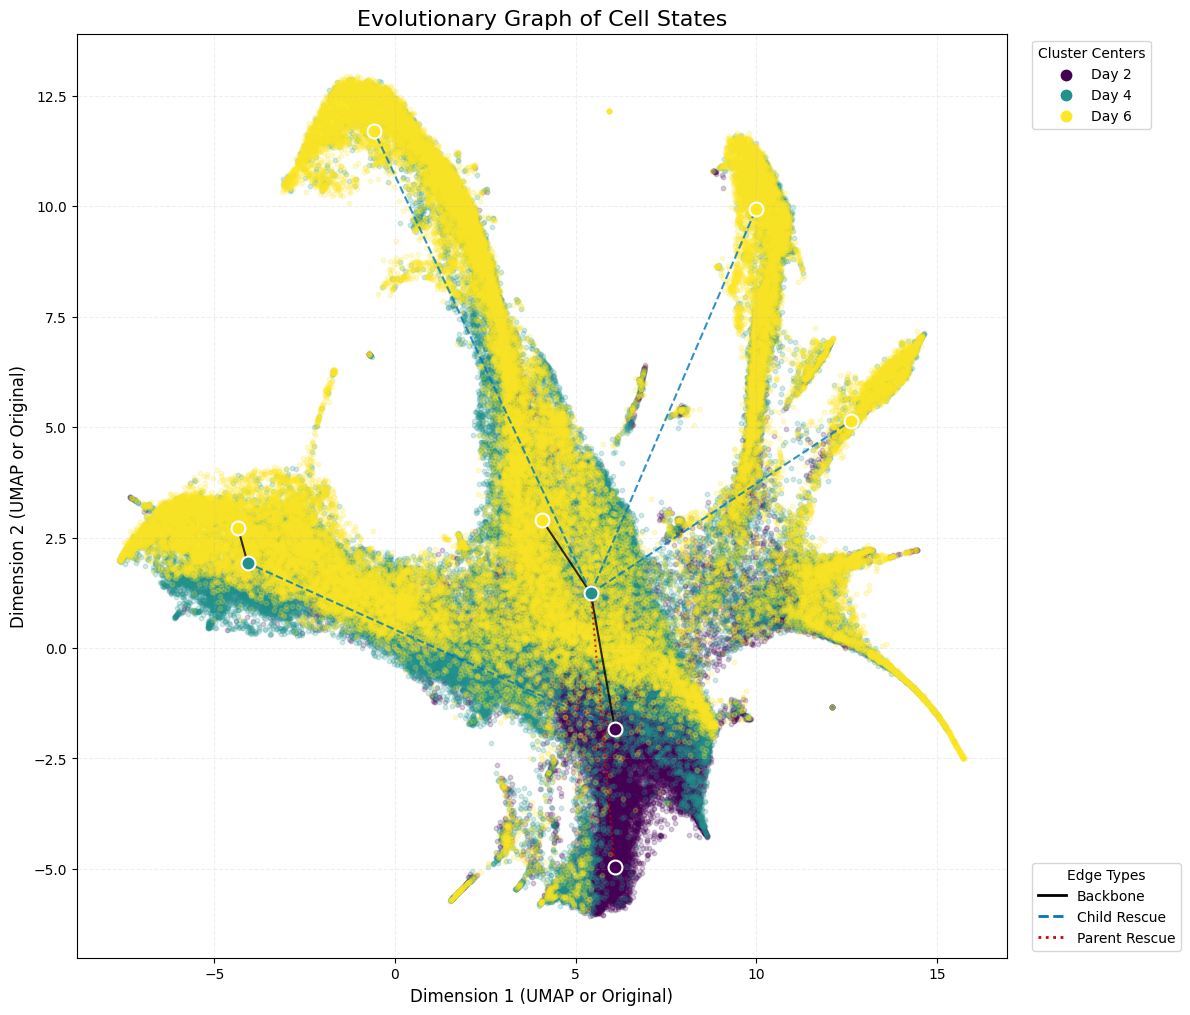

In [9]:

vi.visualize_full_evolution(
    raw_data=[d.cpu().numpy() for d in data_lst],
    centers=[c for c in cluster_centers],
    all_points_map=all_points_map,
    edges=msf_edges,
    time_labels=['Day ' + str(t) for t in time_steps],
    umap_model=um,
    save_path='./weinreb_results/evolution_graph_simplified(26.7.13)'
)
cluster_centers = [torch.from_numpy(c) for c in cluster_centers]

In [11]:
cluster_centers = [c for c in cluster_centers]

In [12]:
import scope.datasets as ds

label_list_for_train = [cl.assign_labels(d.cuda(),cluster_centers[i].cuda()) for i, d in enumerate(data_lst)]

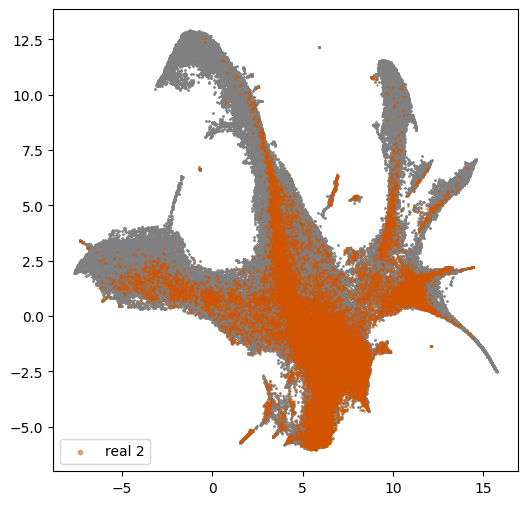

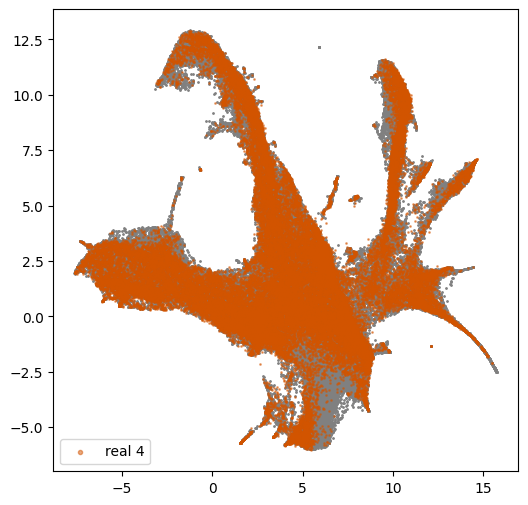

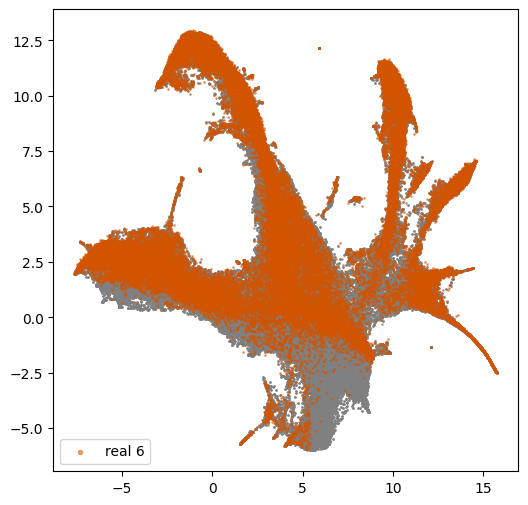

In [13]:
vi.visualize_populations(data_lst,time_steps,umap_model=um,save_path='./weinreb_results/raw_data(26.7.13)')

In [16]:
import scope
from scope import model
steps = 128
eps = eps_func

eps_test = eps_func
sb_object=model.sb_muti_model(data_lst,time_steps,N_pretraining=40,N_finetuning=40,backbone_lr=1e-3,finetuning_lr=1e-3,
                              steps=steps,eps=eps,early_stop=True,patience=8,B=128,lambda_=1e-3,save=True,record_gap=1,save_path='model_history/weinreb_prematched',
                              prematched=True, label_list=label_list_for_train, edges=msf_edges, weighting_strategy='enos', beta=0.999)


INFO: 从演化图中找到了 9 条长度为 3 的有效路径（演化蓝图）。
defaultdict(<class 'float'>, {1: 0.487951614997688, 3: 0.1647894705451004, 2: 0.11161239633050746, 0: 0.059081392481491246, 4: 0.17656512564521284})


In [17]:
#sb_object.backbone_train()
sb_object.backbone_load("/mnt/SCOPE_CODE/model_history/weinreb_prematched/backbone.pt")

/mnt/SCOPE_CODE/scope/model.py:130: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  models_dict=torch.load(model_path)


In [18]:
fore_base=sb_object.eval_fore(data_day2.cuda().double(),sb_object.v_fore)

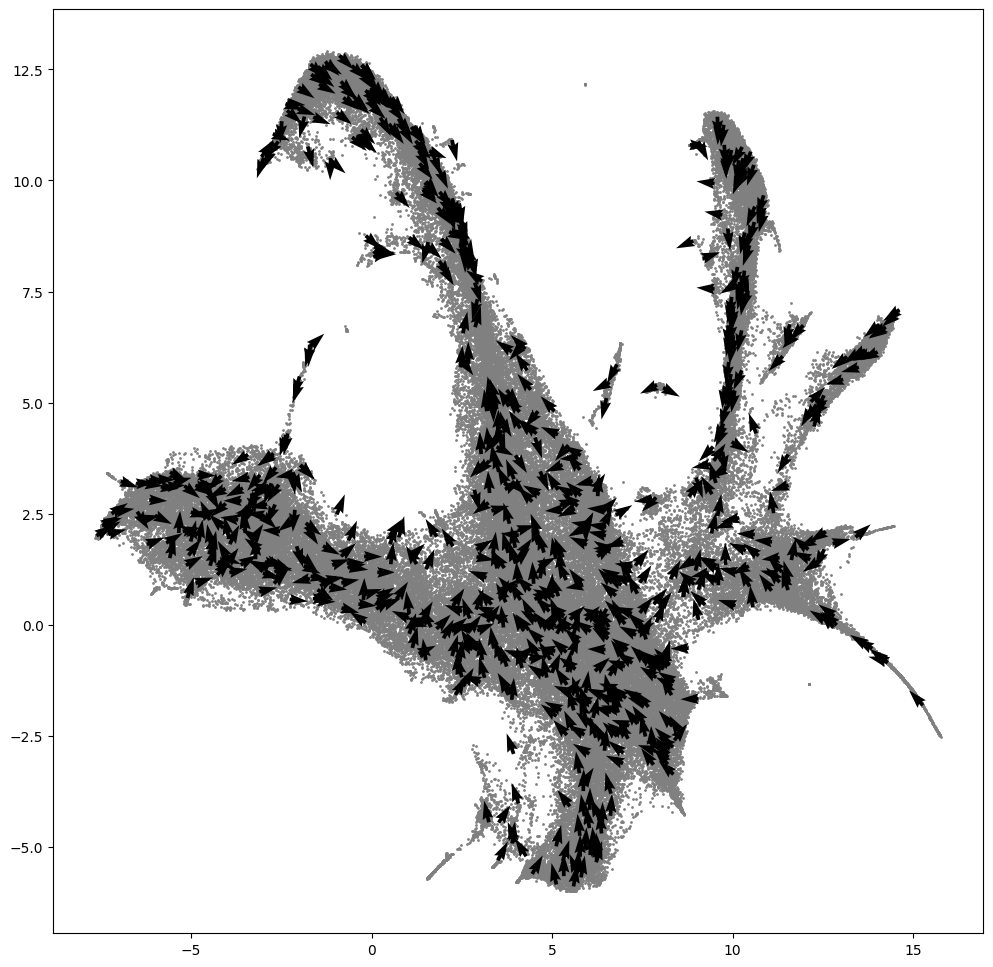

In [19]:
vi.visualize_drift_func([d.cuda() for d in data_lst],xp,sb_object,meta['Time point'].values,um,save_path='./weinreb_results/drift_backbone((26.7.13))')

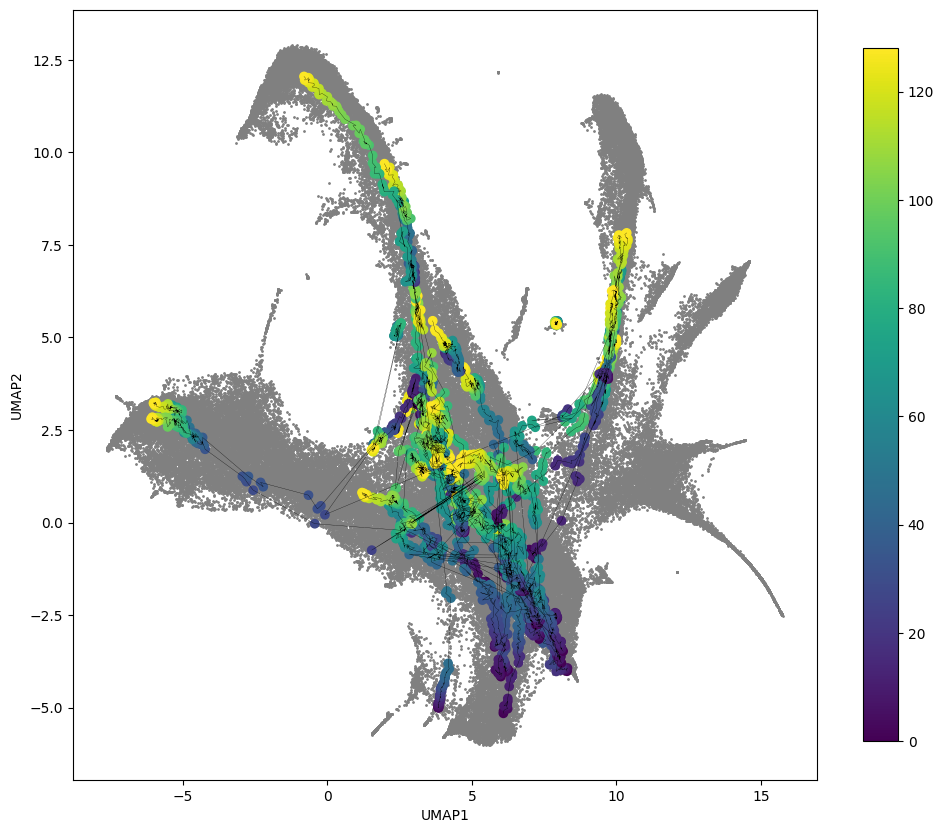

In [20]:
vi.visualize_generated_trajectories(data_lst,fore_base,umap_model=um,save_path='./weinreb_results/generated_trajectories_backbone((26.7.13))')

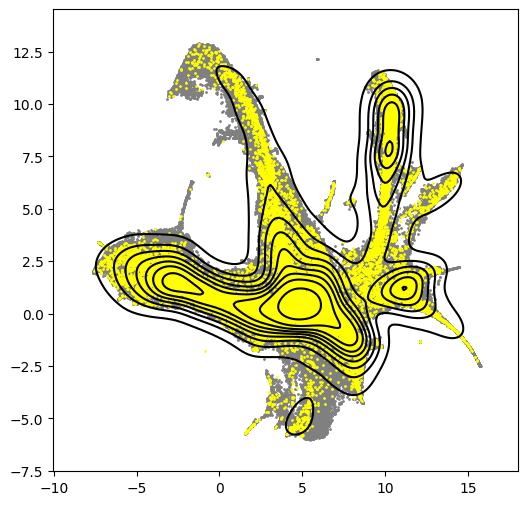

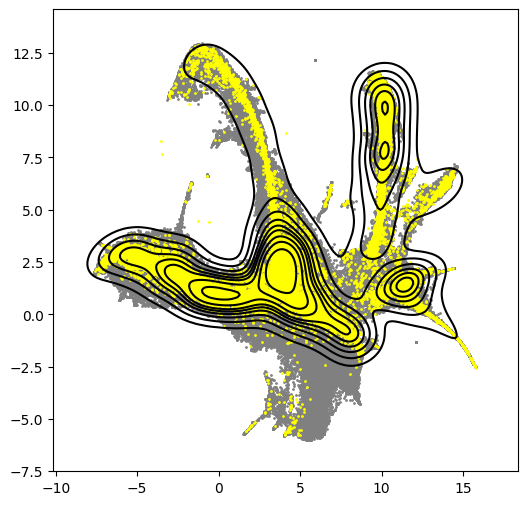

In [21]:
vi.visualize_generated_populations(data_lst,fore_base,time_steps,umap_model=um,save_path='./weinreb_results/generated_populations_backbone((26.7.13))')

In [22]:
#sb_object.fine_tune(change=4)
sb_object.finetuning_load("/mnt/SCOPE_CODE/model_history/weinreb_prematched/fine_tuned.pt")

/mnt/SCOPE_CODE/scope/model.py:138: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  models_dict=torch.load(model_path)


In [26]:
fore_ft=sb_object.eval_fore(data_day2.cuda().double(),sb_object.v_fore_fine_tuned)

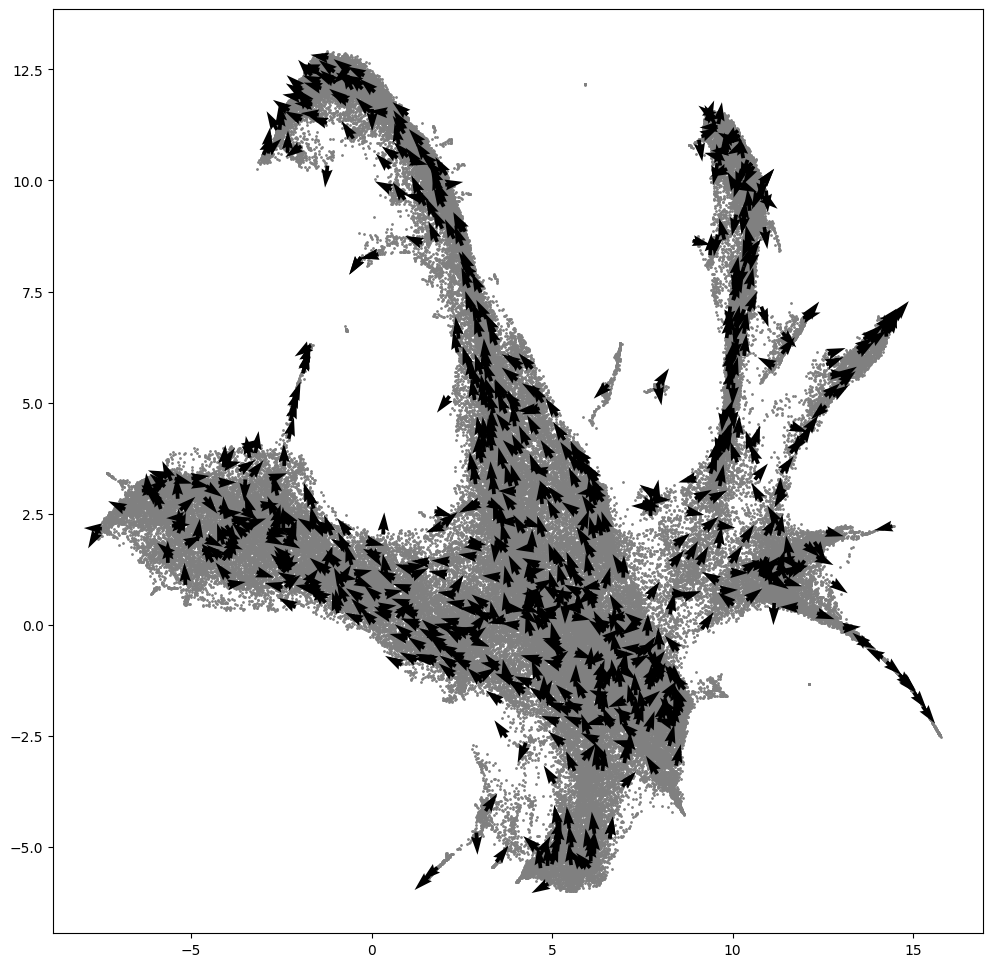

In [27]:
vi.visualize_drift_func(data_lst,xp,sb_object,meta['Time point'].values,umap_model=um,save_path='./weinreb_results/drift_fine_tuned((26.7.13))',fine_tuned=True)

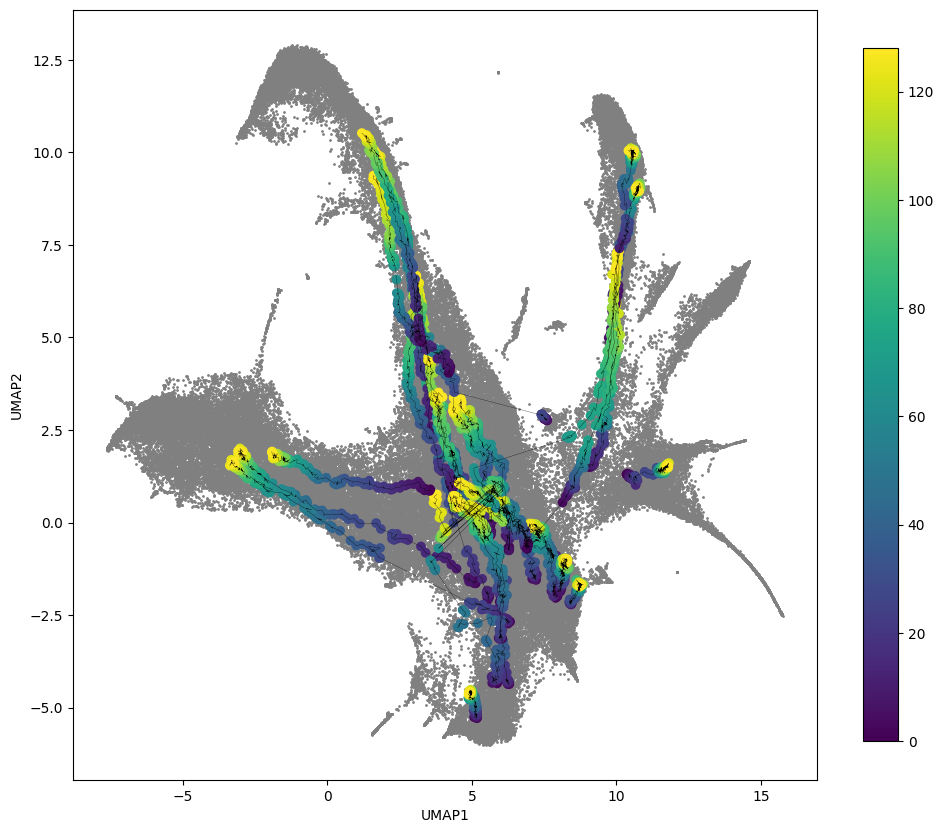

In [28]:
vi.visualize_generated_trajectories(data_lst,fore_ft,umap_model=um,save_path='./weinreb_results/generated_trajectories_fine_tuned((26.7.13))')

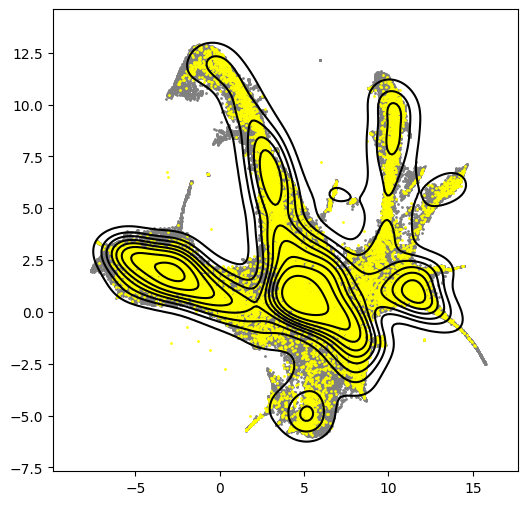

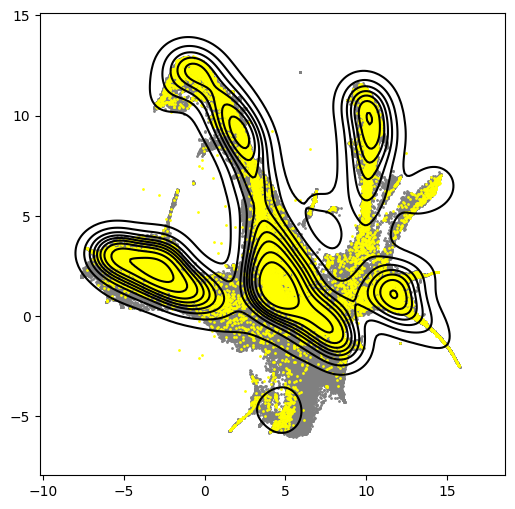

In [29]:
vi.visualize_generated_populations(data_lst,fore_ft,time_steps,umap_model=um,save_path='./weinreb_results/generated_populations_fine_tuned((26.7.5))')

In [30]:
from geomloss import SamplesLoss
ot_solver = SamplesLoss("sinkhorn", p = 2, blur = 0.1, scaling = 0.7,backend='auto')
tensor1 = torch.tensor(data_day4, dtype=torch.float32).contiguous().cuda()
tensor2 = torch.tensor(data_day6, dtype=torch.float32).contiguous().cuda()
tensor3 = torch.tensor(fore_base[len(fore_base)//2], dtype=torch.float32).contiguous().cuda()
tensor4 = torch.tensor(fore_base[-1], dtype=torch.float32).contiguous().cuda()
tensor5 = torch.tensor(fore_ft[len(fore_base)//2], dtype=torch.float32).contiguous().cuda()
tensor6 = torch.tensor(fore_ft[-1], dtype=torch.float32).contiguous().cuda()
print("backbone real4-fake4",ot_solver(tensor1[np.random.choice(data_day4.shape[0],10000),:], tensor3).item())
print("backbone real6-fake6",ot_solver(tensor2[np.random.choice(data_day6.shape[0],10000),:], tensor4).item())
print("finetuned real4-fake4",ot_solver(tensor1[np.random.choice(data_day4.shape[0],10000),:], tensor5).item())
print("finetuned real6-fake6",ot_solver(tensor2[np.random.choice(data_day6.shape[0],10000),:], tensor6).item())

/tmp/ipykernel_185/2662554511.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tensor1 = torch.tensor(data_day4, dtype=torch.float32).contiguous().cuda()
/tmp/ipykernel_185/2662554511.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tensor2 = torch.tensor(data_day6, dtype=torch.float32).contiguous().cuda()
/tmp/ipykernel_185/2662554511.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tensor3 = torch.tensor(fore_base[len(fore_base)//2], dtype=torch.float32).contiguous().cuda()
/tmp/ipykernel_185/2662554511.py:6: UserWarning: To co

backbone real4-fake4 39.38026428222656
backbone real6-fake6 51.94877243041992
finetuned real4-fake4 32.69229507446289
finetuned real6-fake6 37.11598205566406


In [15]:
from sklearn.neighbors import KNeighborsClassifier
xp_day6=xp[meta['Time point']==6].values
y_day6=meta[meta['Time point']==6]['Cell type annotation']
knn=KNeighborsClassifier(n_neighbors=10)
knn.fit(xp_day6,y_day6)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


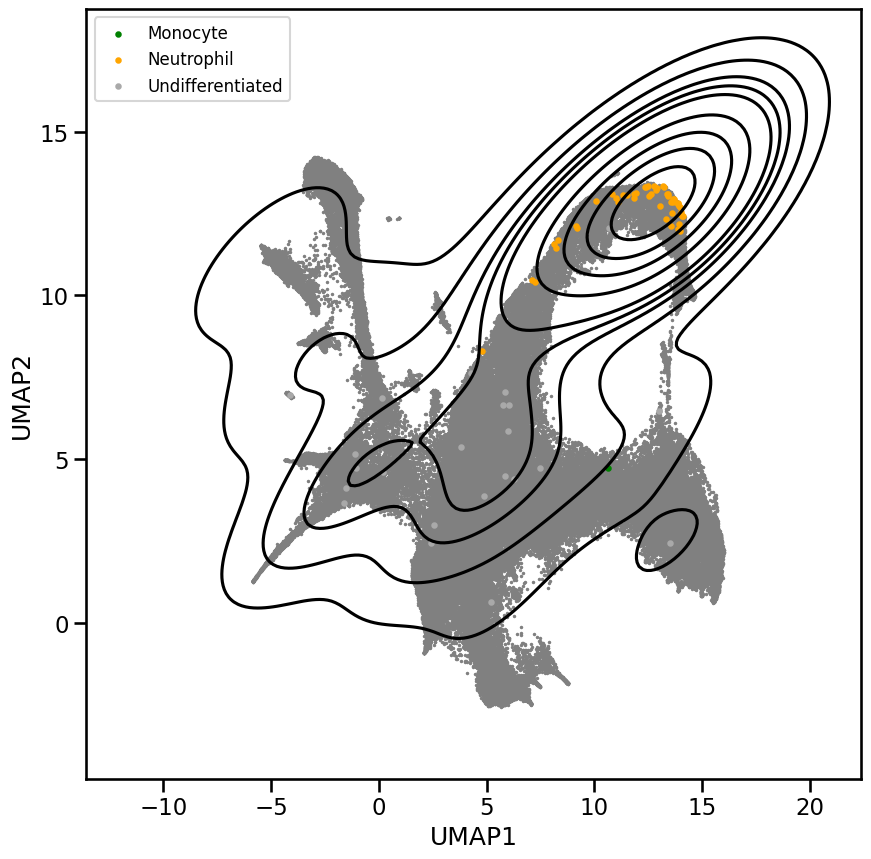

In [49]:
disturb_name=['Cebpe','Dach1','Lmo4','Mxd1']
disturb_values= 5
xs_disturbed=xs.copy()
xs_disturbed.loc[:,disturb_name]=disturb_values
xp_disturbed = pd.DataFrame(pca.transform(xs_disturbed))
data_choose=torch.from_numpy(xp_disturbed[(meta['Time point']==2) & (meta['Cell type annotation']=='Undifferentiated')].values)
data_chosed=data_choose[torch.randperm(data_choose.size(0))[:1000],:]
sim=sb_object.eval_fore(data_chosed,sb_object.v_fore_fine_tuned)
sim=torch.stack(sim,dim=0)

yp=[]
yp.append(knn.predict(sim[-1,:,:]))
labs=pd.DataFrame(yp)

import matplotlib
sns.set_context("talk")
fig,ax = plt.subplots(figsize=(10,10))
ax.scatter(xu[:,0], xu[:,1], s=1, c="gray")

#cmap=["crimson", "dodgerblue", "pink", "purple", "green", "orange", "darkgrey"]
cmap=["green", "orange", "darkgrey"]
num_days, num_paths, num_features = sim.shape
selected_paths = np.random.choice(num_paths, size=80, replace=False)

selected_labels = labs.iloc[0,selected_paths]

day6_points = []
for p in selected_paths:
    path_data = sim[:, p, :]  
    xu_ = um.transform(path_data)  
    day6_points.append(xu_[-1])
day6_points = np.array(day6_points) 

j=0
for lab in np.unique(labs):
    i=np.where(selected_labels==lab)
    if lab in ["Baso", "Eos", "Lymphoid", "Meg", 'Ccr7_DC', 'Erythroid', 'Mast', 'pDC']:
        continue
    ax.scatter(day6_points[i, 0],day6_points[i, 1],s=10, color=cmap[j], label=lab)
    j+=1
#scatter=ax.scatter(temp[:,0], temp[:,1], s=50, cmap=matplotlib.colors.ListedColormap(cmap), c=labs["cellfactor"])
sns.kdeplot(x=day6_points[:, 0], y=day6_points[:, 1], color="k", ax=ax)
legend = ax.legend(loc="upper left",fontsize=12)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.savefig('/mnt/SCOPE_CODE/weinreb_results/cell_distribution_disturb5_fine_tuned.svg')
#plt.axis("off")
plt.show()

In [50]:
from collections import Counter
selected_paths = np.random.choice(num_paths, size=200, replace=False)
num_init=200

num_days, num_paths, num_features = sim.shape
yp = [knn.predict(sim[i, selected_paths, :]) for i in range(sim.shape[0])]
    
# make proportions table
prop_list=[]
for elt in yp:
    prop_dict = {"Undifferentiated":0.0, "Neutrophil":0.0, "Meg":0.0, "Monocyte": 0.0, "Baso": 0.0, "Mast": 0.0, "Lymphoid":0.0, "Erythroid":0.0, "Eos": 0.0, "Ccr7_DC": 0.0, "pDC": 0.0}
    for thing in elt:
        prop_dict[thing]=Counter(elt)[thing]/num_init
    prop_list.append(prop_dict)

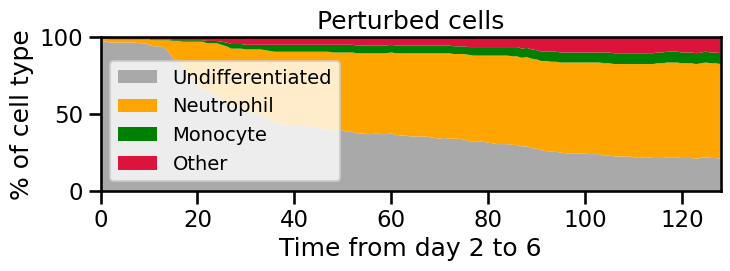

In [51]:
prop_table=pd.DataFrame(prop_list)*100
other_sum = prop_table["Meg"]+prop_table["Baso"]+prop_table["Mast"]+prop_table["Lymphoid"]+prop_table["Erythroid"]+prop_table["Eos"]+prop_table["Ccr7_DC"]+prop_table["pDC"]
prop_table=pd.DataFrame([prop_table["Undifferentiated"],prop_table["Neutrophil"],prop_table["Monocyte"], other_sum]).T
plt.figure(figsize=(8,2))
sns.set_context("talk")
labels=["Undifferentiated", "Neutrophil", "Monocyte", "Other"]
colors=["darkgrey", "orange", "green", "crimson"]
plt.stackplot(np.arange(128+1),  prop_table["Undifferentiated"], 
              prop_table["Neutrophil"],  prop_table["Monocyte"], 
              prop_table["Unnamed 0"], labels=labels, colors=colors)
plt.legend(loc='lower left', prop={'size': 14})
plt.margins(0,0)
plt.title('Perturbed cells')
plt.xlabel("Time from day 2 to 6")
plt.ylabel("% of cell type")
plt.savefig('/mnt/SCOPE_CODE/weinreb_results/cell_percentage_disturb5_fine_tuned.svg')
plt.show()

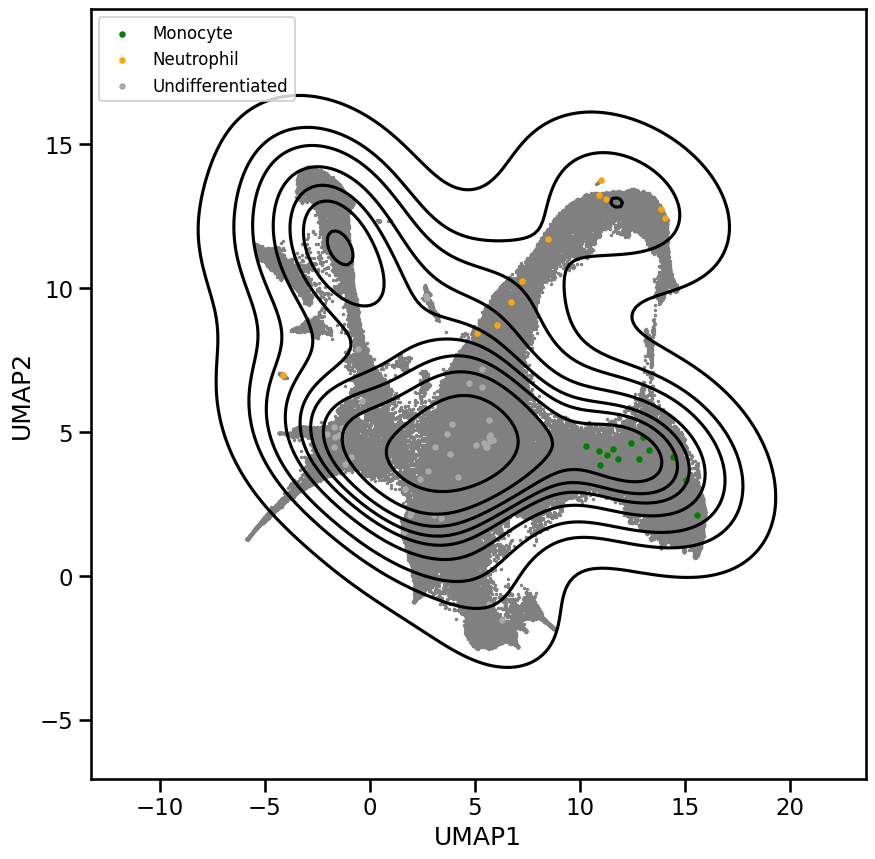

In [52]:
disturb_name=['Cebpe','Dach1','Lmo4','Mxd1']
disturb_values= 0
xs_disturbed=xs.copy()
xs_disturbed.loc[:,disturb_name]=disturb_values
xp_disturbed = pd.DataFrame(pca.transform(xs_disturbed))
data_choose=torch.from_numpy(xp_disturbed[(meta['Time point']==2) & (meta['Cell type annotation']=='Undifferentiated')].values)
data_chosed=data_choose[torch.randperm(data_choose.size(0))[:1000],:]
sim=sb_object.eval_fore(data_chosed,sb_object.v_fore_fine_tuned)
sim=torch.stack(sim,dim=0)

yp=[]
yp.append(knn.predict(sim[-1,:,:]))
labs=pd.DataFrame(yp)

import matplotlib
sns.set_context("talk")
fig,ax = plt.subplots(figsize=(10,10))
ax.scatter(xu[:,0], xu[:,1], s=1, c="gray")

#cmap=["crimson", "dodgerblue", "pink", "purple", "green", "orange", "darkgrey"]
cmap=["green", "orange", "darkgrey"]
num_days, num_paths, num_features = sim.shape
selected_paths = np.random.choice(num_paths, size=80, replace=False)

selected_labels = labs.iloc[0,selected_paths]

day6_points = []
for p in selected_paths:
    path_data = sim[:, p, :]  
    xu_ = um.transform(path_data)  
    day6_points.append(xu_[-1])
day6_points = np.array(day6_points) 

j=0
for lab in np.unique(labs):
    i=np.where(selected_labels==lab)
    if lab in ["Baso", "Eos", "Lymphoid", "Meg", 'Ccr7_DC', 'Erythroid', 'Mast', 'pDC']:
        continue
    ax.scatter(day6_points[i, 0],day6_points[i, 1],s=10, color=cmap[j], label=lab)
    j+=1
#scatter=ax.scatter(temp[:,0], temp[:,1], s=50, cmap=matplotlib.colors.ListedColormap(cmap), c=labs["cellfactor"])
sns.kdeplot(x=day6_points[:, 0], y=day6_points[:, 1], color="k", ax=ax)
legend = ax.legend(loc="upper left",fontsize=12)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.savefig('/mnt/SCOPE_CODE/weinreb_results/cell_distribution_disturb0_fine_tuned.svg')
#plt.axis("off")
plt.show()

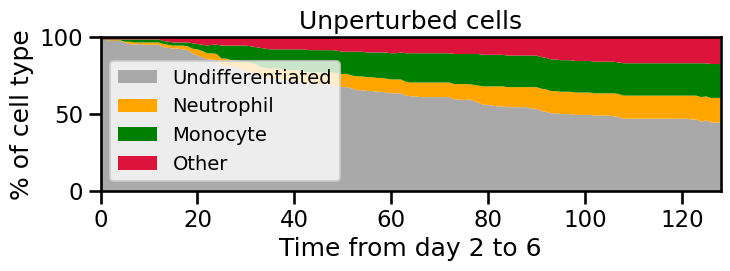

In [53]:
from collections import Counter
selected_paths = np.random.choice(num_paths, size=200, replace=False)
num_init=200

num_days, num_paths, num_features = sim.shape
yp = [knn.predict(sim[i, selected_paths, :]) for i in range(sim.shape[0])]
    
# make proportions table
prop_list=[]
for elt in yp:
    prop_dict = {"Undifferentiated":0.0, "Neutrophil":0.0, "Meg":0.0, "Monocyte": 0.0, "Baso": 0.0, "Mast": 0.0, "Lymphoid":0.0, "Erythroid":0.0, "Eos": 0.0, "Ccr7_DC": 0.0, "pDC": 0.0}
    for thing in elt:
        prop_dict[thing]=Counter(elt)[thing]/num_init
    prop_list.append(prop_dict)

prop_table=pd.DataFrame(prop_list)*100
other_sum = prop_table["Meg"]+prop_table["Baso"]+prop_table["Mast"]+prop_table["Lymphoid"]+prop_table["Erythroid"]+prop_table["Eos"]+prop_table["Ccr7_DC"]+prop_table["pDC"]
prop_table=pd.DataFrame([prop_table["Undifferentiated"],prop_table["Neutrophil"],prop_table["Monocyte"], other_sum]).T
plt.figure(figsize=(8,2))
sns.set_context("talk")
labels=["Undifferentiated", "Neutrophil", "Monocyte", "Other"]
colors=["darkgrey", "orange", "green", "crimson"]
plt.stackplot(np.arange(128+1),  prop_table["Undifferentiated"], 
              prop_table["Neutrophil"],  prop_table["Monocyte"], 
              prop_table["Unnamed 0"], labels=labels, colors=colors)
plt.legend(loc='lower left', prop={'size': 14})
plt.margins(0,0)
plt.title('Unperturbed cells')
plt.xlabel("Time from day 2 to 6")
plt.ylabel("% of cell type")
plt.savefig('/mnt/SCOPE_CODE/weinreb_results/cell_percentage_disturb0_fine_tuned.svg')
plt.show()

In [38]:
def predict_fate(sim,knn):
    yp=[]
    for i in range(sim.shape[0]):
        yp.append(knn.predict(sim[i,:,:]))
    df=pd.DataFrame(yp)
    #score=((df.eq('Neutrophil')).sum(axis=1)+1)/((df.eq('Neutrophil')).sum(axis=1)+(df.eq('Monocyte')).sum(axis=1)+2)
    score1=((df.eq('Neutrophil')).sum(axis=1)+1)/1000
    score2=((df.eq('Monocyte')).sum(axis=1)+1)/1000
    return score1.values, score2.values   

In [ ]:
disturb_name=['Cebpe','Dach1','Lmo4','Mxd1']
disturb_values=[0,2.5,5,10,-2.5,-5,-10]
box_result1=[]
box_result2=[]
for i in disturb_values:
    xs_disturbed=xs.copy()
    if i!=0:
        xs_disturbed.loc[:,disturb_name]=i
    xp_disturbed = pd.DataFrame(pca.transform(xs_disturbed))
    data_choose=torch.from_numpy(xp_disturbed[(meta['Time point']==2) & (meta['Cell type annotation']=='Undifferentiated')].values)
    sim_result=[]
    for n in range(20):
        data_chosed=data_choose[torch.randperm(data_choose.size(0))[:1000],:]
        sim_result.append(sb_object.eval_fore(data_chosed,sb_object.v_fore_fine_tuned)[-1])
    sim_result=torch.stack(sim_result)
    temp1,temp2 = predict_fate(sim_result,knn)
    box_result1.append(temp1)
    box_result2.append(temp2)

/tmp/ipykernel_25132/2312416064.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  box.set_xticklabels(["unperturbed","2.5","5","10","-2.5","-5","-10"])


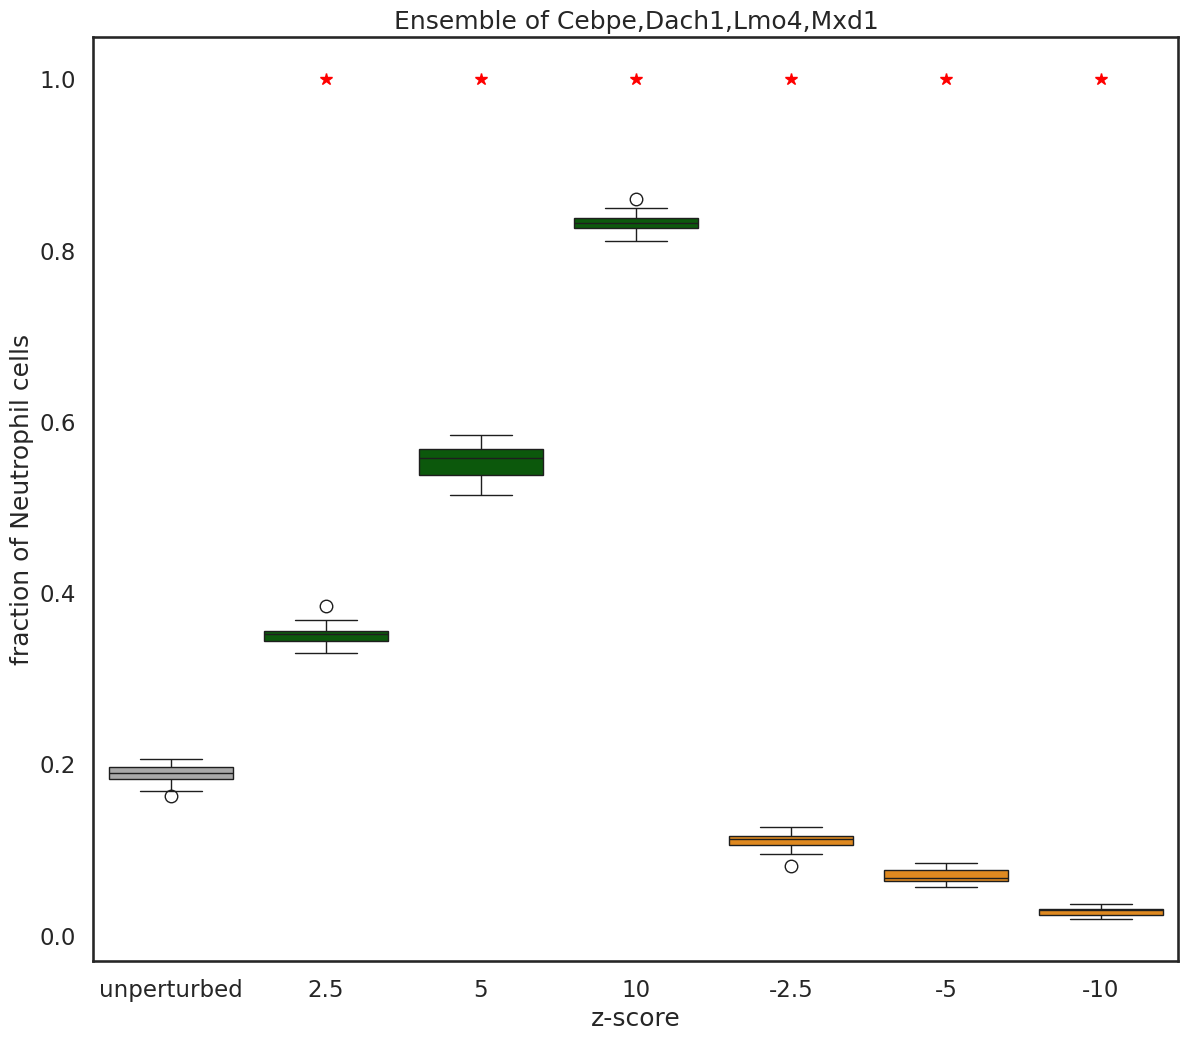

/tmp/ipykernel_25132/2312416064.py:83: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  box.set_xticklabels(["unperturbed","2.5","5","10","-2.5","-5","-10"])


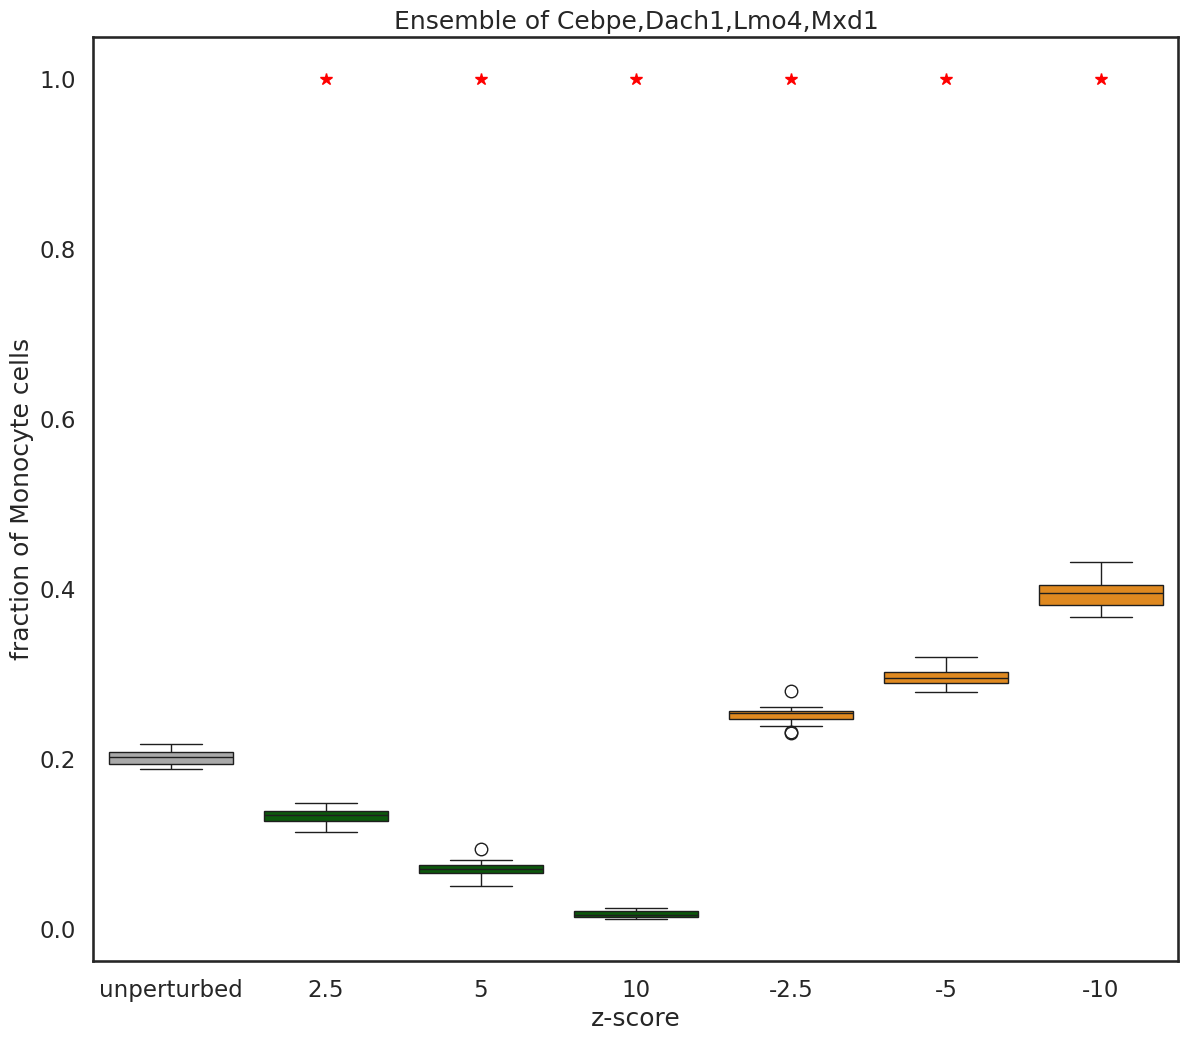

In [45]:

    
    
fig, ax = plt.subplots(figsize=(14,12), sharex=True, sharey=True)#len(filenames)/3, figsize=(10,20))
sns.set_context("talk")
sns.set_style("white")
#mypal=["lightgrey","sandybrown","sienna","brown"]
mypal=["darkgrey", "darkgreen", "darkgreen", "darkgreen", "darkorange", "darkorange","darkorange"]
#mypal=["lightgrey","white", "lightgray", "darkgray"]
ax.set_title("Ensemble of Cebpe,Dach1,Lmo4,Mxd1")
#ax.set_ylim(0.4,0.7)
for j in range(1, 7):
    #stat, p = scipy.stats.mannwhitneyu(neu_dist_all[i][0], neu_dist_all[i][j], alternative="greater")
    stat, p = scipy.stats.ttest_ind(box_result1[0], box_result1[j], equal_var=False)
    x1, x2 = 0,j
    if p < .05:
        y=1
        ax.plot(x2, y, "*", c="r")
box=sns.boxplot(data=np.array(box_result1).T, ax=ax, palette=mypal)
box.set_xticklabels(["unperturbed","2.5","5","10","-2.5","-5","-10"])
box.set_ylabel("fraction of Neutrophil cells")
ax.set_xlabel("z-score")
plt.savefig(
            'Ncell_prematched.svg', 
            format='svg',
            dpi=1200,                
            bbox_inches='tight',    
            pad_inches=0.1          
        )
plt.show()
plt.close()


fig, ax = plt.subplots(figsize=(14,12), sharex=True, sharey=True)#len(filenames)/3, figsize=(10,20))
sns.set_context("talk")
sns.set_style("white")
#mypal=["lightgrey","sandybrown","sienna","brown"]
mypal=["darkgrey", "darkgreen", "darkgreen", "darkgreen", "darkorange", "darkorange","darkorange"]
#mypal=["lightgrey","white", "lightgray", "darkgray"]
ax.set_title("Ensemble of Cebpe,Dach1,Lmo4,Mxd1")
#ax.set_ylim(0.4,0.7)
for j in range(1, 7):
    #stat, p = scipy.stats.mannwhitneyu(neu_dist_all[i][0], neu_dist_all[i][j], alternative="greater")
    stat, p = scipy.stats.ttest_ind(box_result2[0], box_result2[j], equal_var=False)
    x1, x2 = 0,j
    if p < .05:
        y=1
        ax.plot(x2, y, "*", c="r")
box=sns.boxplot(data=np.array(box_result2).T, ax=ax, palette=mypal)
box.set_xticklabels(["unperturbed","2.5","5","10","-2.5","-5","-10"])
box.set_ylabel("fraction of Monocyte cells")
ax.set_xlabel("z-score")
plt.savefig(
            'Mcell_prematched.svg', 
            format='svg',
            dpi=1200,                
            bbox_inches='tight',    
            pad_inches=0.1          
        )
plt.show()

/tmp/ipykernel_25132/1082394798.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  box.set_xticklabels(["unperturbed","2.5","5","10","-2.5","-5","-10"])


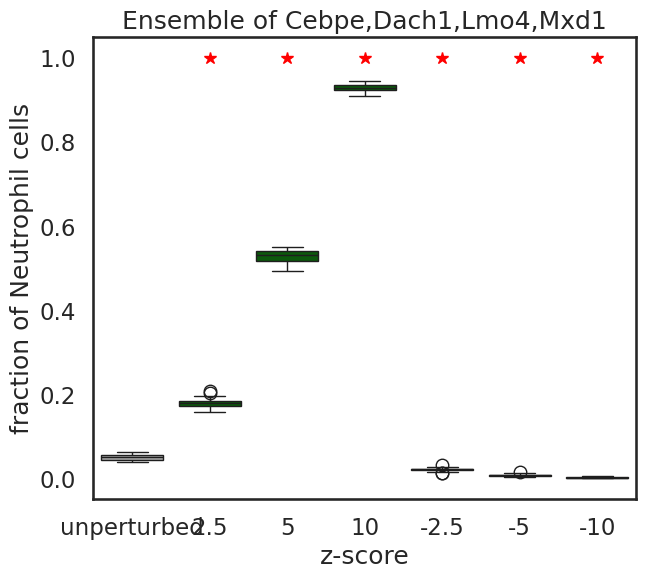

/tmp/ipykernel_25132/1082394798.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  box.set_xticklabels(["unperturbed","2.5","5","10","-2.5","-5","-10"])


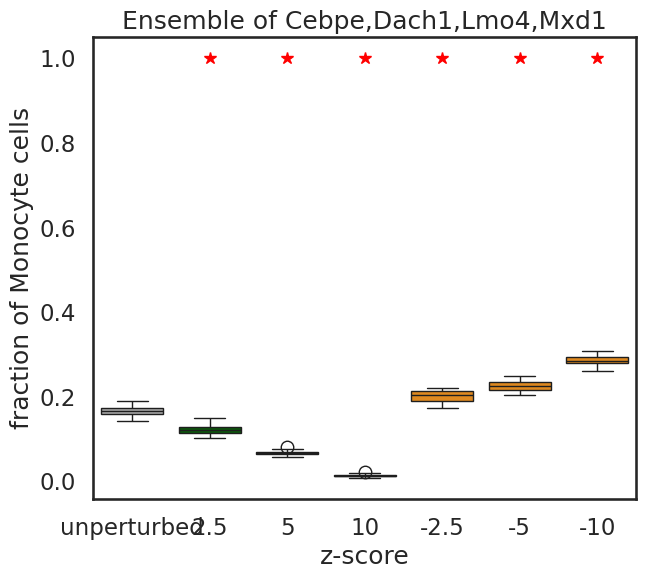

In [23]:
from sklearn.neighbors import KNeighborsClassifier
xp_day6=xp[meta['Time point']==6].values
y_day6=meta[meta['Time point']==6]['Cell type annotation']
knn=KNeighborsClassifier(n_neighbors=10)
knn.fit(xp_day6,y_day6)
def predict_fate(sim,knn):
    yp=[]
    for i in range(sim.shape[0]):
        yp.append(knn.predict(sim[i,:,:]))
    df=pd.DataFrame(yp)
    #score=((df.eq('Neutrophil')).sum(axis=1)+1)/((df.eq('Neutrophil')).sum(axis=1)+(df.eq('Monocyte')).sum(axis=1)+2)
    score1=((df.eq('Neutrophil')).sum(axis=1)+1)/1000
    score2=((df.eq('Monocyte')).sum(axis=1)+1)/1000
    return score1.values, score2.values   


disturb_name=['Cebpe','Dach1','Lmo4','Mxd1']
disturb_values=[0,2.5,5,10,-2.5,-5,-10]
box_result1=[]
box_result2=[]
for i in disturb_values:
    xs_disturbed=xs.copy()
    if i!=0:
        xs_disturbed.loc[:,disturb_name]=i
    xp_disturbed = pd.DataFrame(pca.transform(xs_disturbed))
    data_choose=torch.from_numpy(xp_disturbed[(meta['Time point']==2) & (meta['Cell type annotation']=='Undifferentiated')].values)
    sim_result=[]
    for n in range(20):
        data_chosed=data_choose[torch.randperm(data_choose.size(0))[:1000],:]
        sim_result.append(sb_object.eval_fore(data_chosed,sb_object.v_fore)[-1])
    sim_result=torch.stack(sim_result)
    temp1,temp2 = predict_fate(sim_result,knn)
    box_result1.append(temp1)
    box_result2.append(temp2)
    
    
fig, ax = plt.subplots(figsize=(7,6), sharex=True, sharey=True)#len(filenames)/3, figsize=(10,20))
sns.set_context("talk")
sns.set_style("white")
#mypal=["lightgrey","sandybrown","sienna","brown"]
mypal=["darkgrey", "darkgreen", "darkgreen", "darkgreen", "darkorange", "darkorange","darkorange"]
#mypal=["lightgrey","white", "lightgray", "darkgray"]
ax.set_title("Ensemble of Cebpe,Dach1,Lmo4,Mxd1")
#ax.set_ylim(0.4,0.7)
for j in range(1, 7):
    #stat, p = scipy.stats.mannwhitneyu(neu_dist_all[i][0], neu_dist_all[i][j], alternative="greater")
    stat, p = scipy.stats.ttest_ind(box_result1[0], box_result1[j], equal_var=False)
    x1, x2 = 0,j
    if p < .05:
        y=1
        ax.plot(x2, y, "*", c="r")
box=sns.boxplot(data=np.array(box_result1).T, ax=ax, palette=mypal)
box.set_xticklabels(["unperturbed","2.5","5","10","-2.5","-5","-10"])
box.set_ylabel("fraction of Neutrophil cells")
ax.set_xlabel("z-score")
plt.show()


fig, ax = plt.subplots(figsize=(7,6), sharex=True, sharey=True)#len(filenames)/3, figsize=(10,20))
sns.set_context("talk")
sns.set_style("white")
#mypal=["lightgrey","sandybrown","sienna","brown"]
mypal=["darkgrey", "darkgreen", "darkgreen", "darkgreen", "darkorange", "darkorange","darkorange"]
#mypal=["lightgrey","white", "lightgray", "darkgray"]
ax.set_title("Ensemble of Cebpe,Dach1,Lmo4,Mxd1")
#ax.set_ylim(0.4,0.7)
for j in range(1, 7):
    #stat, p = scipy.stats.mannwhitneyu(neu_dist_all[i][0], neu_dist_all[i][j], alternative="greater")
    stat, p = scipy.stats.ttest_ind(box_result2[0], box_result2[j], equal_var=False)
    x1, x2 = 0,j
    if p < .05:
        y=1
        ax.plot(x2, y, "*", c="r")
box=sns.boxplot(data=np.array(box_result2).T, ax=ax, palette=mypal)
box.set_xticklabels(["unperturbed","2.5","5","10","-2.5","-5","-10"])
box.set_ylabel("fraction of Monocyte cells")
ax.set_xlabel("z-score")
plt.show()

clone ws-loss

In [24]:
timepoints=meta["Time point"]
import scipy.io as sio
clone= sio.mmread("stateFate_inVitro_clone_matrix.mtx.gz")
dense_clone= clone.todense()
dense_clone.shape

(130887, 5864)

In [25]:
df_dense_clone=pd.DataFrame(dense_clone)
num_clone=df_dense_clone.sum(axis=0).sort_values(ascending=False)
num_clone.head(20)

1261    177
2370    165
5714    142
292     134
5209    130
3345    124
1843    117
2256    112
5150    108
2673    107
4256    105
2539     99
4758     97
1325     95
3612     95
3165     93
3438     93
5789     92
3869     90
3250     90
dtype: int64

In [26]:
day2_clones = df_dense_clone[timepoints == 2]
day2_clones = day2_clones.sum(axis=0)>0
meta_ = meta.copy()
np_clone = df_dense_clone.to_numpy()
meta_['clone'] = np.asarray(np.argmax(np_clone, axis = 1))[:]
meta_.loc[np.asarray(np_clone.sum(axis = 1) == 0), 'clone'] = -1
nc = meta_.loc[meta_['clone'] != -1]
nc = nc.groupby(['clone'])['Time point'].value_counts().unstack().fillna(0).astype(int)
nc.head(20)

Time point,2,4,6
clone,,,
0,0,2,3
1,0,13,7
2,1,14,5
3,0,2,0
4,0,3,6
5,1,0,5
6,1,0,1
7,0,1,1
8,0,3,3


In [27]:
cloneindex=nc.loc[(nc.iloc[:,0]>0)&(nc.iloc[:,1]>0)&(nc.iloc[:,2]>0)&(nc.iloc[:,0]+nc.iloc[:,2]+nc.iloc[:,2]>5),:].index

In [28]:
day2_index=[]
clone_index = cloneindex
for i, clone_id in enumerate(clone_index):
    index1 = df_dense_clone.loc[df_dense_clone.loc[:, clone_id] == 1, clone_id].index
    px = meta["id"].isin(index1)
    pxx= (meta["id"].isin(index1)) &(meta["Time point"] == 2)
    list=meta.loc[pxx,:].index
    day2_index.append(list)
day4_index=[]
clone_index = cloneindex
for i, clone_id in enumerate(clone_index):
    index1 = df_dense_clone.loc[df_dense_clone.loc[:, clone_id] == 1, clone_id].index
    px = meta["id"].isin(index1)
    pxx= (meta["id"].isin(index1)) &(meta["Time point"] == 4)
    list=meta.loc[pxx,:].index
    day4_index.append(list)
day6_index=[]
clone_index = cloneindex
for i, clone_id in enumerate(clone_index):
    index1 = df_dense_clone.loc[df_dense_clone.loc[:, clone_id] == 1, clone_id].index
    px = meta["id"].isin(index1)
    pxx= (meta["id"].isin(index1)) &(meta["Time point"] == 6)
    list=meta.loc[pxx,:].index
    day6_index.append(list)

In [29]:
px

0         False
1         False
2         False
3         False
4         False
          ...  
130882    False
130883    False
130884    False
130885    False
130886    False
Name: id, Length: 130887, dtype: bool

In [30]:
all_xps = []
all_xps_backbone = []
device = torch.device('cuda:0')

for i in range(len(day2_index)):
    px = day2_index[i]
    x_i = torch.from_numpy(xp.values[px]).to(device)  # (m, feature_dim)
    n = len(day6_index[i]) 

    sample_indices = torch.randint(0, len(x_i), (n,), device=x_i.device)
    repeated_xi = x_i[sample_indices]
    all_xps.append(np.stack(sb_object.eval_fore(repeated_xi, sb_object.v_fore_fine_tuned)))
    all_xps_backbone.append(np.stack(sb_object.eval_fore(repeated_xi, sb_object.v_fore)))

In [31]:
all_xpsday4 = []  
all_xpsday4_backbone = []  
for i in range(len(day2_index)):
    px = day2_index[i]
    x_i = torch.from_numpy(xp.values[px]).to(device)  # (m, feature_dim)
    n = len(day4_index[i])  

    sample_indices = torch.randint(0, len(x_i), (n,), device=x_i.device)
    repeated_xi = x_i[sample_indices]
    all_xpsday4.append(np.stack(
        cmp.generate_one_stage(sb_object.t_lists_stage,
                                   repeated_xi.double().cuda(),
                                   sb_object.v_fore_fine_tuned,
                                   sb_object.scale_m_fore,
                                   sb_object.delta_t,
                                   sb_object.eps,
                                   1)
    ))
    all_xpsday4_backbone.append(np.stack(
        cmp.generate_one_stage(sb_object.t_lists_stage,
                                   repeated_xi.double().cuda(),
                                   sb_object.v_fore,
                                   sb_object.scale_m_fore,
                                   sb_object.delta_t,
                                   sb_object.eps,
                                   1)
    ))

In [32]:
xps_day6_ref= []  
for i in range(len(day2_index)):
    px = day6_index[i]
    x_i = torch.from_numpy(xp.values[px]).to(device)  
    xps_day6_ref.append(x_i) 

xps_day4_ref= []  
for i in range(len(day2_index)):
    px = day4_index[i]
    x_i = torch.from_numpy(xp.values[px]).to(device)  
    xps_day4_ref.append(x_i) 

xps_day2_ref= [] 
for i in range(len(day2_index)):
    px = day2_index[i]
    x_i = torch.from_numpy(xp.values[px]).to(device)  
    xps_day2_ref.append(x_i) 

In [33]:
from geomloss import SamplesLoss
ot_solver = SamplesLoss("sinkhorn", p = 2, blur = 0.1, scaling = 0.7)
ot_results_day6 = []
ot_results_day6_backbone = []
for i in range(len(xps_day6_ref)):
    array1 = xps_day6_ref[i]
    tensor1 = torch.tensor(array1, dtype=torch.float32).to(device)
    array2 = all_xps[i][-1,:,:]
    tensor2 = torch.tensor(array2, dtype=torch.float32).to(device)
    ot_distance=ot_solver(tensor1, tensor2)
    ot_results_day6.append(ot_distance.item())
    array3 = all_xps_backbone[i][-1,:,:]
    ot_distance=ot_solver(tensor1, tensor3)
    ot_results_day6_backbone.append(ot_distance.item())

/tmp/ipykernel_25132/682994412.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tensor1 = torch.tensor(array1, dtype=torch.float32).to(device)


In [34]:
ot_results_day4 = []
ot_results_day4_backbone = []
for i in range(len(xps_day4_ref)):
    array1 = xps_day4_ref[i]
    tensor1 = torch.tensor(array1, dtype=torch.float32).to(device)
    array2 = all_xpsday4[i][-1,:,:]
    tensor2 = torch.tensor(array2, dtype=torch.float32).to(device)
    ot_distance=ot_solver(tensor1, tensor2)
    ot_results_day4.append(ot_distance.item())
    array3 = all_xpsday4_backbone[i][-1,:,:]
    tensor3 = torch.tensor(array3, dtype=torch.float32).to(device)
    ot_distance=ot_solver(tensor1, tensor3)
    ot_results_day4_backbone.append(ot_distance.item())

/tmp/ipykernel_25132/3449775981.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tensor1 = torch.tensor(array1, dtype=torch.float32).to(device)


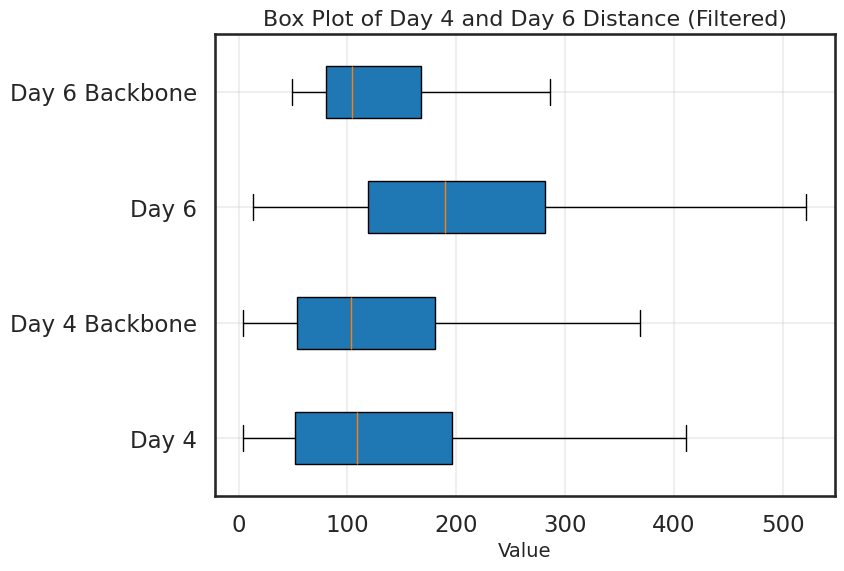

In [35]:

# day4_distance_filtered = [x for x in day4_distance if x <= 1000]
# day6_distance_filtered = [x for x in day6_distance if x <= 1000]


plt.figure(figsize=(8, 6))
plt.boxplot([ot_results_day4, ot_results_day4_backbone, ot_results_day6, ot_results_day6_backbone], 
            vert=False, 
            patch_artist=True,showfliers=False)


plt.title('Box Plot of Day 4 and Day 6 Distance (Filtered)', fontsize=16)
plt.xlabel('Value', fontsize=14)
plt.yticks([1, 2, 3, 4], ['Day 4','Day 4 Backbone', 'Day 6','Day 6 Backbone'])  # 设置每个箱型图的标签
plt.grid(alpha=0.3)
plt.show()
#plt.savefig("/mnt/weinreb2025.3.26/result/figure/clone_lossbox.svg", dpi=500)

In [36]:
xps_clone_ref_combined = []

for x2, x4, x6 in zip(xps_day2_ref, xps_day4_ref, xps_day6_ref):
    combined = torch.cat([x2, x4, x6], dim=0)
    xps_clone_ref_combined.append(combined)
xps_clone_sim_combined = []
xps_clone_sim_combined_backbone = []
for x2, x4, x4_backbone, x6, x6_backbone in zip(xps_day2_ref, all_xpsday4, all_xpsday4_backbone, all_xps, all_xps_backbone):
    if isinstance(x4, np.ndarray):
        x4 = torch.from_numpy(x4).to(x2.device)
    if isinstance(x6, np.ndarray):
        x6 = torch.from_numpy(x6).to(x2.device)
    if isinstance(x4_backbone, np.ndarray):
        x4_backbone = torch.from_numpy(x4_backbone).to(x2.device)
    if isinstance(x6_backbone, np.ndarray):
        x6_backbone = torch.from_numpy(x6_backbone).to(x2.device)
    combined = torch.cat([x2, x4[-1,:,:], x6[-1,:,:]], dim=0)
    xps_clone_sim_combined.append(combined)
    combined = torch.cat([x2, x4_backbone[-1,:,:], x6_backbone[-1,:,:]], dim=0)
    xps_clone_sim_combined_backbone.append(combined)

In [37]:
ot_solver = SamplesLoss("sinkhorn", p = 2, blur = 0.1, 
                    scaling = 0.7)
ot_results_full_clone = []
ot_results_full_clone_backbone = []
for i in range(len(xps_clone_sim_combined)):
    array1 = xps_clone_sim_combined[i]
    tensor1 = torch.tensor(array1, dtype=torch.float32).to(device)
    array2 = xps_clone_ref_combined[i]
    tensor2 = torch.tensor(array2, dtype=torch.float32).to(device)
    ot_distance=ot_solver(tensor1, tensor2)
    ot_results_full_clone.append(ot_distance.item())
    
    array3 = xps_clone_sim_combined_backbone[i]
    tensor3 = torch.tensor(array3, dtype=torch.float32).to(device)
    ot_distance=ot_solver(tensor3, tensor2)
    ot_results_full_clone_backbone.append(ot_distance.item())

/tmp/ipykernel_25132/1767875816.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tensor1 = torch.tensor(array1, dtype=torch.float32).to(device)
/tmp/ipykernel_25132/1767875816.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tensor2 = torch.tensor(array2, dtype=torch.float32).to(device)
/tmp/ipykernel_25132/1767875816.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tensor3 = torch.tensor(array3, dtype=torch.float32).to(device)


{'whiskers': [<matplotlib.lines.Line2D at 0x7f7ab0a35300>,
 'caps': [<matplotlib.lines.Line2D at 0x7f7ab0a35900>,
 'boxes': [<matplotlib.patches.PathPatch at 0x7f7ab0a34fd0>],
 'medians': [<matplotlib.lines.Line2D at 0x7f7ab0a35f00>],
 'fliers': [],
 'means': []}

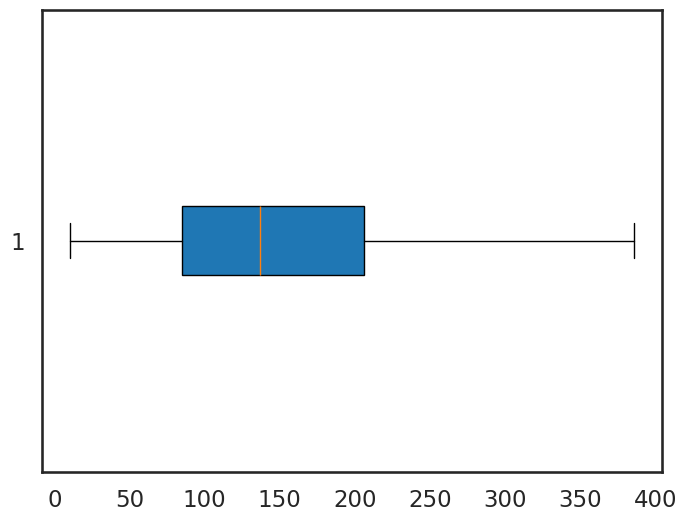

In [38]:
plt.figure(figsize=(8, 6))
plt.boxplot(ot_results_full_clone, 
            vert=False, 
            patch_artist=True,showfliers=False)

In [39]:
print(len(ot_results_full_clone))

677


In [40]:
print(len(ot_results_day4))

677


In [41]:
print(len(ot_results_day6))

677


In [42]:
clone_w_results = pd.DataFrame()
clone_w_results['day4'] = ot_results_day4
clone_w_results['day6'] = ot_results_day6
clone_w_results['full'] = ot_results_full_clone
clone_w_results['day4_backbone'] = ot_results_day4_backbone
clone_w_results['day6_backbone'] = ot_results_day6_backbone
clone_w_results['full_backbone'] = ot_results_full_clone_backbone
clone_w_results.to_csv('clone_w_results_weinreb.csv')

In [43]:
clone_w_results

,day4,day6,full,day4_backbone,day6_backbone,full_backbone
0,293.087708,219.744263,244.239868,356.937012,256.656799,269.166077
1,132.407791,46.376179,57.529625,134.165512,67.931656,93.532196
2,42.960361,174.235077,147.835175,62.316166,104.580231,155.625214
3,65.073914,109.694641,79.661301,46.830902,68.595284,69.491814
4,53.719727,307.687286,237.875778,191.998413,75.176414,161.521484
...,...,...,...,...,...,...
672,135.592438,51.999435,74.461449,135.488586,79.391876,79.733612
673,218.953064,68.618378,52.390907,238.701263,68.646294,110.206657
674,345.563354,34.040352,71.751282,338.736877,71.193382,81.670876
675,31.590242,186.261368,118.589424,141.833679,154.919189,224.046616
